In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

In [2]:
# Read in cleaned dataset
X_with_urn = pd.read_csv('./model_data/final_features.csv') 
y = pd.read_csv('./model_data/labels.csv')  # 1 = target, 0 = non-target

entity_urns = X_with_urn['entity_urn'].copy()

X = X_with_urn.drop(columns=['entity_urn'])

In [3]:
# Separate targets and non-targets
targets = X[y.values == 1]   
non_targets = X[y.values == 0]  

In [4]:
# Split targets into Train/Val/Test manually
targets_train, targets_temp = train_test_split(
    targets, test_size=0.4, random_state=42
)
targets_val, targets_test = train_test_split(
    targets_temp, test_size=0.5, random_state=42
)

# Now split non-targets similarly
non_targets_train, non_targets_temp = train_test_split(
    non_targets, test_size=0.4, random_state=42
)
non_targets_val, non_targets_test = train_test_split(
    non_targets_temp, test_size=0.5, random_state=42
)

In [5]:
# Combine targets and non-targets back
X_train = pd.concat([targets_train, non_targets_train])
y_train = pd.Series([1]*len(targets_train) + [0]*len(non_targets_train))

X_val = pd.concat([targets_val, non_targets_val])
y_val = pd.Series([1]*len(targets_val) + [0]*len(non_targets_val))

X_test = pd.concat([targets_test, non_targets_test])
y_test = pd.Series([1]*len(targets_test) + [0]*len(non_targets_test))

In [6]:
# # Shuffle each set (important so targets aren't clustered at top)
# For Train
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

train_data = X_train.copy()
train_data['label'] = y_train

train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_train = train_data['label']
X_train = train_data.drop(columns=['label'])

# # For Validation
X_val = X_val.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)

val_data = X_val.copy()
val_data['label'] = y_val
val_data = val_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_val = val_data['label']
X_val = val_data.drop(columns=['label'])

# # For Test
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

test_data = X_test.copy()
test_data['label'] = y_test
test_data = test_data.sample(frac=1, random_state=42).reset_index(drop=True)

y_test = test_data['label']
X_test = test_data.drop(columns=['label'])

In [7]:
# Check
print("Train targets:", (y_train == 1).sum())
print("Validation targets:", (y_val == 1).sum())
print("Test targets:", (y_test == 1).sum())

print(f"Train size: {X_train.shape}, Validation size: {X_val.shape}, Test size: {X_test.shape}")

Train targets: 36
Validation targets: 12
Test targets: 13
Train size: (8937, 30), Validation size: (2979, 30), Test size: (2980, 30)


In [8]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 247.25


In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'scale_pos_weight': [scale_pos_weight],  
}

xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist,
    n_iter=20,  # try 20 random combinations
    scoring='average_precision',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit to training data
random_search.fit(X_train, y_train)

# Best Model
print("Best Hyperparameters:", random_search.best_params_)
print(f"Best Validation CV AP Score: {random_search.best_score_:.4f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=9, n_estimators=700, scale_pos_weight=247.25, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=9, n_estimators=700, scale_pos_weight=247.25, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.1, max_depth=9, n_estimators=700, scale_pos_weight=247.25, subsample=0.7; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.1, max_depth=7, n_estimators=300, scale_pos_weight=247.25, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.1, max_depth=7, n_estimators=300, scale_pos_weight=247.25, subsample=0.9; total time=   0.3s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.1, max_depth=9, n_estimators=700, scale_pos_weight=247.25, subsample=0.9; total time=   0.5s
[CV] END colsample_bytree=0.9, gamm

In [10]:
# model with best hyper params
best_xgb = random_search.best_estimator_

Validation Set AP Score (Best XGBoost): 0.9248


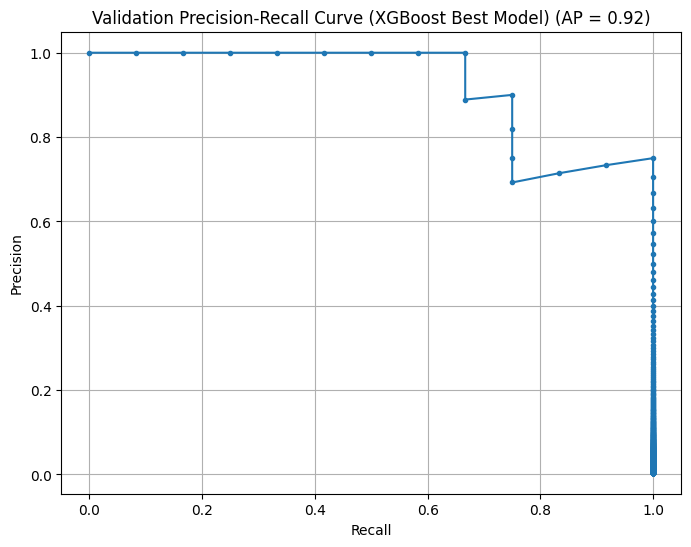

In [11]:
# Predict probabilities
y_val_pred_proba = best_xgb.predict_proba(X_val)[:, 1]

# Calculate AP score
ap_val = average_precision_score(y_val, y_val_pred_proba)
print(f"Validation Set AP Score (Best XGBoost): {ap_val:.4f}")

# Plot Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.title(f'Validation Precision-Recall Curve (XGBoost Best Model) (AP = {ap_val:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()

In [12]:
# Retrain on Full Training + Validation Set

# Combine training and validation sets
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

# Manually set up a new XGBoost model with the best params
final_xgb_model = xgb.XGBClassifier(
    **random_search.best_params_,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

# Retrain
final_xgb_model.fit(X_final_train, y_final_train)

/Users/tiffanylin/ansa-case-study/.venv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [00:31:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0.5, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [13]:
y_test_pred_proba = final_xgb_model.predict_proba(X_test)[:, 1]
ap_test = average_precision_score(y_test, y_test_pred_proba)

print(f"Test AP Score: {ap_test:.4f}")

Test AP Score: 0.9593


## Evaluate on full dataset

In [14]:
# Predict similarity scores
similarity_scores = final_xgb_model.predict_proba(X)[:, 1]

# Attach to company IDs
scored_companies = pd.DataFrame({
    'entity_urn': entity_urns,  # update with your real ID column
    'similarity_score': similarity_scores
})

scored_companies.sort_values(by='similarity_score', ascending=False, inplace=True)

# Save results
scored_companies.to_csv('company_similarity_scores.csv', index=False)


In [15]:
scored_companies

,entity_urn,similarity_score
14,urn:harmonic:company:2178345,9.999940e-01
19,urn:harmonic:company:9609784,9.999905e-01
10,urn:harmonic:company:2003862,9.999832e-01
37,urn:harmonic:company:796251,9.999827e-01
40,urn:harmonic:company:4424857,9.999750e-01
...,...,...
7424,urn:harmonic:company:8226893,6.553648e-08
6816,urn:harmonic:company:9380259,6.441996e-08
4789,urn:harmonic:company:3867542,6.083115e-08
6438,urn:harmonic:company:11718744,5.660988e-08


In [16]:
target_company_data = pd.read_parquet('./case_study_data/target_company_data.parquet')
target_company_data = target_company_data['entity_urn'].to_frame()

In [18]:
target_company_data.merge(scored_companies, how="left", on="entity_urn")

,entity_urn,similarity_score
0,urn:harmonic:company:1443095,0.999953
1,urn:harmonic:company:1990249,0.999796
2,urn:harmonic:company:3075425,0.999899
3,urn:harmonic:company:10819970,0.998959
4,urn:harmonic:company:3928206,0.999903
...,...,...
56,urn:harmonic:company:1842794,0.999878
57,urn:harmonic:company:48201423,0.998008
58,urn:harmonic:company:773593,0.999224
59,urn:harmonic:company:1869576,0.999357


In [19]:
print(np.min(similarity_scores), np.max(similarity_scores))

5.310758e-08 0.99999404
